# Traitement d'images médicales : analyse d'IRM au format DICOM

Projet réalisé dans le cadre du cours de traitement d'images médicales (ISIS Castres, 2025).

## Objectif

Construire une chaîne de traitement complète sur des coupes d'IRM (cerveau et cou) : lire le format DICOM, **mesurer** la qualité d'une image (contraste, histogramme, entropie), **comparer quantitativement** plusieurs techniques de rehaussement du contraste, puis **segmenter** des structures par seuillage et morphologie mathématique.

## Plan

0. Configuration
1. Lecture et exploration d'une image DICOM
2. Mesurer la qualité de l'image : contraste, histogramme, entropie
3. Rehaussement du contraste : égalisation d'histogramme, CLAHE, étirement linéaire
4. Segmentation et morphologie mathématique (nettoyage d'une image binaire, détection de marqueurs sur une IRM, comptage d'objets sur une image satellite)
5. Conclusion

## Données (non versionnées)

- `N2D_0273.dcm` : coupe axiale passant par le milieu du cerveau, où les structures sont bien visibles (parties 1 à 3). Elle provient du dépôt public [datalad/example-dicom-structural](https://github.com/datalad/example-dicom-structural).
- `N2D_0001.dcm` : coupe axiale passant par le cou (colonne vertébrale et épaules visibles), sur laquelle 4 petits points brillants sont à isoler ; elle n'est utilisée que pour la partie 4.2.
- `cell.png` : image binaire bruitée fournie avec le cours (partie 4.1).
- `moliets.png` : image satellite fournie avec le cours (partie 4.3)

## 0. Configuration

In [1]:
%pip install -q pydicom scikit-image

In [2]:
import sys, os

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/'      # dossier contenant les fichiers (à adapter)
else:
    DATA_DIR = './data'

DICOM_FILE      = os.path.join(DATA_DIR, 'N2D_0273.dcm')   # parties 1 à 3
DICOM_MARQUEURS = os.path.join(DATA_DIR, 'N2D_0001.dcm')   # partie 4.2
CELL_FILE       = os.path.join(DATA_DIR, 'cell.png')       # partie 4.1
MOLIETS_FILE    = os.path.join(DATA_DIR, 'moliets.png')    # partie 4.3

for f in (DICOM_FILE, DICOM_MARQUEURS, CELL_FILE, MOLIETS_FILE):
    print('OK       ' if os.path.exists(f) else 'MANQUANT', f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OK        /content/drive/MyDrive/N2D_0273.dcm
OK        /content/drive/MyDrive/N2D_0001.dcm
OK        /content/drive/MyDrive/cell.png
OK        /content/drive/MyDrive/moliets.png


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydicom import dcmread
import skimage.io as io
from skimage import exposure, color
from skimage.measure import shannon_entropy, label, regionprops
from skimage.filters import threshold_otsu
from skimage.morphology import disk, erosion, dilation, opening, closing
from scipy import ndimage as ndi
import matplotlib.patheffects as pe

## 1. Lecture et exploration d'une image DICOM

Le format DICOM stocke l'image **et** ses métadonnées : modalité, géométrie, résolution spatiale, informations patient. La coupe est lue avec `pydicom`, puis on examine ses caractéristiques techniques : taille, type de données, plage d'intensités et résolution physique.

Les champs qui identifient le patient ne sont volontairement jamais affichés : seules les métadonnées techniques le sont.

### 1.1 Chargement et caractéristiques techniques

Métadonnées techniques :
  Modality       : MR
  Rows           : 384
  Columns        : 274
  PixelSpacing   : [0.666666686534882, 0.699987828731537]
  SliceThickness : 0.666666686534882
  BitsAllocated  : 16
  BitsStored     : 16

Dimensions (lignes, colonnes) : (384, 274)
Type de données : int16
Intensités : min = 0, max = 91, 92 niveaux distincts
Bits réellement utilisés : 6.5 sur 16 alloués


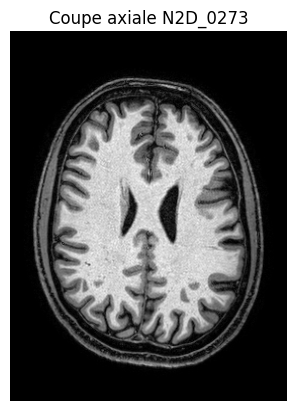

In [4]:
ds = dcmread(DICOM_FILE)
im = ds.pixel_array

print("Métadonnées techniques :")
for tag in ['Modality', 'Rows', 'Columns', 'PixelSpacing', 'SliceThickness', 'BitsAllocated', 'BitsStored']:
    print(f"  {tag:15s}: {getattr(ds, tag, 'non renseigné')}")

print(f"\nDimensions (lignes, colonnes) : {im.shape}")
print(f"Type de données : {im.dtype}")
print(f"Intensités : min = {im.min()}, max = {im.max()}, {np.unique(im).size} niveaux distincts")
print(f"Bits réellement utilisés : {np.log2(im.max() - im.min() + 1):.1f} sur {im.dtype.itemsize * 8} alloués")

# Les pixels ne sont pas carrés : on corrige le rapport d'aspect à l'affichage
pas_ligne, pas_colonne = (float(v) for v in ds.PixelSpacing)
plt.imshow(im, cmap='gray', aspect=pas_ligne / pas_colonne)
plt.axis('off'); plt.title('Coupe axiale N2D_0273'); plt.show()

**Ce qu'on observe.** Image IRM (modalité MR) de 384 × 274 pixels, stockée en `int16` (16 bits alloués). Les intensités ne vont que de 0 à 91, soit 92 niveaux distincts : environ 6,5 bits réellement utilisés sur 16. La résolution est de 0,667 × 0,700 mm par pixel pour une épaisseur de coupe de 0,667 mm : les pixels ne sont pas carrés (écart d'environ 5 %), ce que corrige le paramètre `aspect` à l'affichage.

**Ce qu'on retient.** Le type de stockage ne dit rien de la plage utile : il faut toujours inspecter les valeurs réelles. Ici la plage utile est étroite, ce qui conditionne la suite (l'entropie maximale possible est de log₂(92) ≈ 6,52 bits).

### 1.2 Palettes de couleurs

Une IRM est une image d'intensités, sans couleur propre. Une palette ne fait que recoder les niveaux de gris en couleurs : elle n'ajoute aucune information, mais change ce que l'œil distingue. On compare quatre palettes.

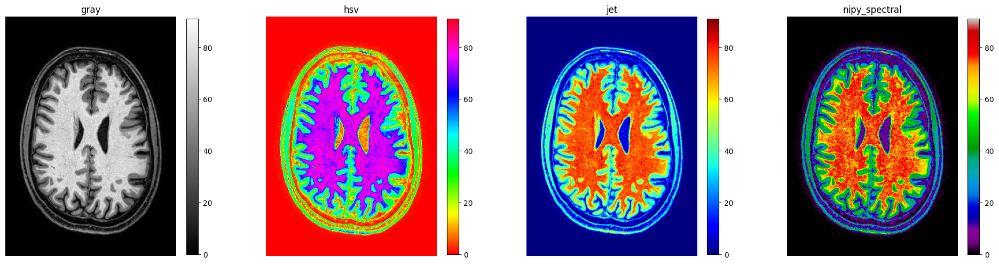

In [5]:
cmaps = ['gray', 'hsv', 'jet', 'nipy_spectral']
fig, axes = plt.subplots(1, len(cmaps), figsize=(5 * len(cmaps), 5))
for ax, cm in zip(axes, cmaps):
    h = ax.imshow(im, cmap=cm)
    ax.set_title(cm); ax.axis('off')
    fig.colorbar(h, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

**Ce qu'on observe.**
- `gray` : référence, lecture naturelle des tissus.
- `hsv` : palette circulaire. Le fond (0) est rouge, et en haut de l'échelle la couleur revient vers le rose/rouge : les deux extrémités de l'échelle se ressemblent, ce qui est trompeur pour une grandeur qui n'est pas cyclique.
- `jet` et `nipy_spectral` : le contraste apparent entre tissus est fort, mais leur luminosité varie de façon irrégulière, ce qui peut faire apparaître de fausses frontières ; le grain de la substance blanche y est aussi plus visible.

**Ce qu'on retient.** Pour l'analyse d'images médicales, le niveau de gris (palette monotone) reste le choix par défaut. Une fausse couleur sert à mettre en évidence un seuil ou une classe, pas à « ajouter » de l'information.

### 1.3 Profils d'intensité

Un profil est la suite des valeurs des pixels le long d'une ligne ou d'une colonne. Il permet de lire quantitativement l'intensité des tissus traversés : plateaux (tissu homogène) et transitions (interfaces).

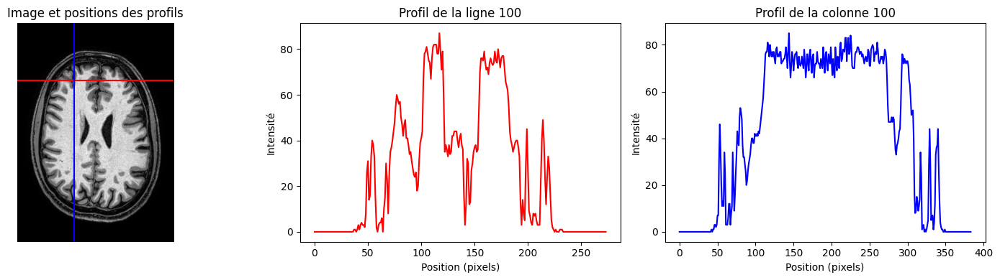

In [6]:
LIGNE, COLONNE = 100, 100

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(im, cmap='gray')
ax[0].axhline(LIGNE, color='r'); ax[0].axvline(COLONNE, color='b')
ax[0].set_title('Image et positions des profils'); ax[0].axis('off')
ax[1].plot(im[LIGNE, :], color='r'); ax[1].set_title(f'Profil de la ligne {LIGNE}')
ax[2].plot(im[:, COLONNE], color='b'); ax[2].set_title(f'Profil de la colonne {COLONNE}')
for a in ax[1:]:
    a.set_xlabel('Position (pixels)'); a.set_ylabel('Intensité')
plt.tight_layout(); plt.show()

**Ce qu'on observe.**
- Hors de la tête, l'intensité est nulle. Le cuir chevelu et l'os produisent de petits pics (de l'ordre de 30 à 50).
- La substance blanche forme un plateau autour de 75 à 80 (deux plateaux de part et d'autre de la scissure sur la ligne 100, un long plateau sur la colonne 100).
- La substance grise se situe autour de 40 ; le liquide céphalo-rachidien (sillons, ventricules) descend vers 0 à 10.
- Sur la colonne, le plateau de substance blanche fluctue entre environ 68 et 85 : c'est le bruit de l'image.

**Ce qu'on retient.** Les tissus se distinguent par leur niveau moyen (≈ 0-10, 40, 75-80). Le bruit reste petit devant l'écart entre substance grise et substance blanche (≈ 35 niveaux), donc les deux tissus sont séparables.

## 2. Mesurer la qualité de l'image : contraste, histogramme, entropie

Avant d'améliorer une image, il faut pouvoir **mesurer** sa qualité. On utilise deux mesures de contraste (Michelson et RMS), l'histogramme et l'entropie de Shannon. Les calculs sont faits en `float` pour éviter tout dépassement d'entiers sur du `int16`. On distingue l'image entière de la **tête seule** (pixels > 0) : une grande partie de l'image est du fond sans information.

### 2.1 Contraste de Michelson et contraste RMS

$$C_M=\frac{im_{max}-im_{min}}{im_{max}+im_{min}} \qquad C_{RMS}=\sqrt{\frac{1}{MN-1}\sum_{i,j}\left(im(i,j)-\overline{im}\right)^2}$$

Michelson ne dépend que des deux pixels extrêmes ; le RMS (écart-type des intensités) mesure la dispersion de tous les pixels.

In [7]:
imf = im.astype(float)            # float : évite un dépassement d'entiers sur du int16
masque_tete = imf > 0             # région d'intérêt : exclut le fond (air)

def contraste_michelson(a):
    return (a.max() - a.min()) / (a.max() + a.min())

def contraste_rms(a):
    return a.std(ddof=1)          # formule avec 1/(MN-1)

tableau = pd.DataFrame({
    'Michelson': [contraste_michelson(imf), contraste_michelson(imf[masque_tete])],
    'RMS': [contraste_rms(imf), contraste_rms(imf[masque_tete])],
}, index=['Image entière', 'Tête seule (fond exclu)']).round(4)
print(tableau)

                         Michelson      RMS
Image entière               1.0000  29.0448
Tête seule (fond exclu)     0.9783  27.7922


**Ce qu'on observe.** Michelson vaut 1,0000 sur l'image entière (le minimum est 0) et 0,9783 sur la tête seule (minimum 1, maximum 91). Le RMS vaut 29,04 sur l'image entière et 27,79 sur la tête seule.

**Ce qu'on retient.** Michelson est ici peu informatif : il est proche de 1 dès que l'image contient un pixel très sombre et un pixel très brillant, même si les tissus occupent une plage étroite. Le RMS est plus représentatif, car il tient compte de tous les pixels ; c'est lui qui servira à comparer les traitements.

### 2.2 Histogramme et entropie de Shannon

L'histogramme donne le nombre de pixels par niveau de gris. Normalisé, c'est une distribution de probabilité $p_k$, dont on tire l'entropie de Shannon $H=-\sum_k p_k\log_2 p_k$ : une mesure, en bits, de la quantité d'information de l'image. Elle est maximale, égale à $\log_2 N$, quand les $N$ niveaux sont équiprobables. Le calcul est fait avec scikit-image, puis refait à la main pour vérification.

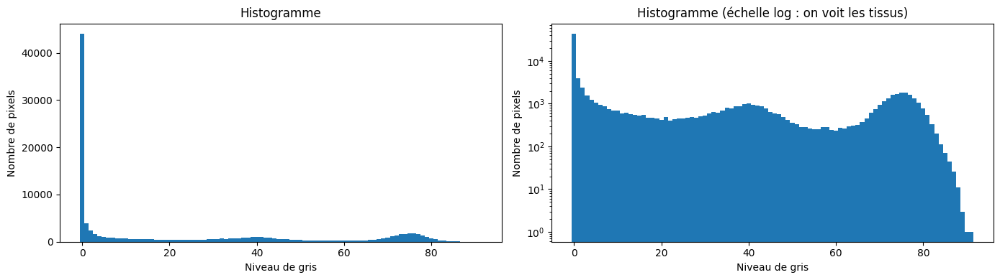

Entropie (skimage)           : 4.5238 bits
Entropie (formule à la main) : 4.5238 bits
Entropie maximale pour 92 niveaux : 6.5236 bits
Part de pixels à 0 (fond) : 41.8%


In [8]:
hist, niveaux = exposure.histogram(im)       # entiers : un bin par niveau de gris
p = hist / hist.sum()                        # histogramme normalisé = probabilités

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(niveaux, hist, width=1.0); ax[0].set_title('Histogramme')
ax[1].bar(niveaux, hist, width=1.0); ax[1].set_yscale('log')
ax[1].set_title('Histogramme (échelle log : on voit les tissus)')
for a in ax:
    a.set_xlabel('Niveau de gris'); a.set_ylabel('Nombre de pixels')
plt.tight_layout(); plt.show()

H = shannon_entropy(im)
H_main = -np.sum(p[p > 0] * np.log2(p[p > 0]))
n_niveaux = np.unique(im).size
print(f"Entropie (skimage)           : {H:.4f} bits")
print(f"Entropie (formule à la main) : {H_main:.4f} bits")
print(f"Entropie maximale pour {n_niveaux} niveaux : {np.log2(n_niveaux):.4f} bits")
print(f"Part de pixels à 0 (fond) : {(im == 0).mean():.1%}")

**Ce qu'on observe.** Le pic à 0 (fond) rassemble 41,8 % des pixels. En échelle logarithmique, on voit deux bosses pour les tissus, vers 40 (substance grise) et vers 75 (substance blanche), séparées par un plateau (liquide, interfaces). L'entropie vaut 4,5238 bits (même valeur par la formule à la main), pour un maximum de 6,5236 bits avec 92 niveaux : l'image utilise environ 69 % de sa capacité d'information.

**Ce qu'on retient.** L'image n'est pas « plate » : sa dynamique est bien utilisée (0 à 91), mais son histogramme est dominé par le fond. C'est la clé de la suite : toute méthode qui exploite l'histogramme global sera influencée par ces 42 % de fond.

## 3. Rehaussement du contraste

On compare trois familles de méthodes, avec les deux critères mesurés plus haut : l'**entropie** (information conservée) et le **contraste RMS de la tête** (lisibilité des tissus).

### 3.1 Égalisation d'histogramme

L'égalisation applique à chaque niveau sa fréquence cumulée, de façon à rendre l'histogramme le plus uniforme possible. Trois variantes sont comparées : **globale**, **restreinte à la tête** (le fond est exclu du calcul grâce à un masque) et **adaptative locale (CLAHE)**, qui égalise par petites régions en limitant l'amplification du bruit.

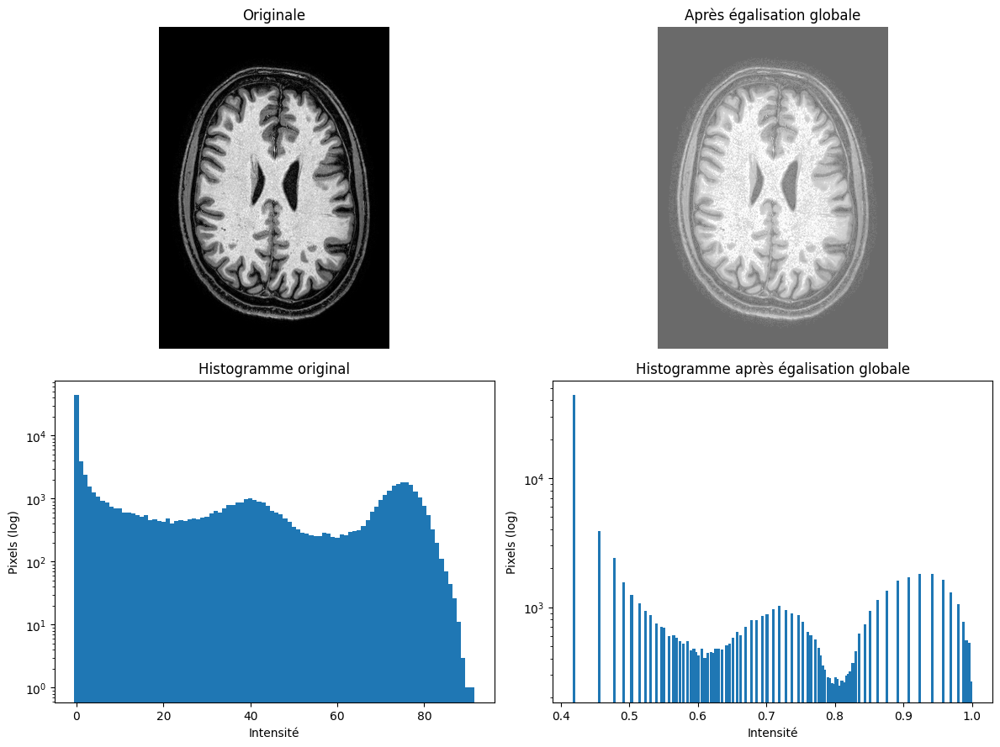

Entropie originale : 4.5238 bits
Entropie égalisée  : 4.5238 bits


In [9]:
im_eq = exposure.equalize_hist(im)           # égalisation globale, float dans [0, 1]

fig, ax = plt.subplots(2, 2, figsize=(12, 9))
ax[0, 0].imshow(im, cmap='gray'); ax[0, 0].set_title('Originale'); ax[0, 0].axis('off')
ax[0, 1].imshow(im_eq, cmap='gray', vmin=0, vmax=1); ax[0, 1].set_title("Après égalisation globale"); ax[0, 1].axis('off')
h0, c0 = exposure.histogram(im)
h1, c1 = exposure.histogram(im_eq, nbins=256)
ax[1, 0].bar(c0, h0, width=1.0); ax[1, 0].set_title('Histogramme original')
ax[1, 1].bar(c1, h1, width=1 / 256); ax[1, 1].set_title("Histogramme après égalisation globale")
for a in ax[1]:
    a.set_yscale('log'); a.set_xlabel('Intensité'); a.set_ylabel('Pixels (log)')
plt.tight_layout(); plt.show()

print(f"Entropie originale : {shannon_entropy(im):.4f} bits")
print(f"Entropie égalisée  : {shannon_entropy(im_eq):.4f} bits")

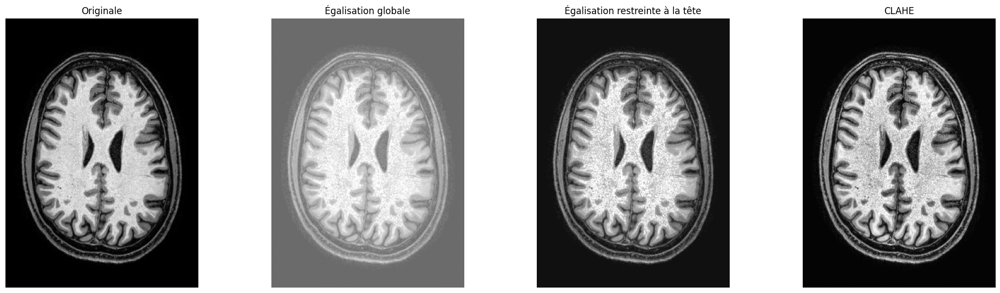

In [10]:
im_eq_tete = exposure.equalize_hist(im, mask=masque_tete)    # fonction de répartition calculée sur la tête seule
imn = (imf - imf.min()) / (imf.max() - imf.min())            # image normalisée dans [0, 1]
im_clahe = exposure.equalize_adapthist(imn, clip_limit=0.02) # égalisation adaptative locale

fig, ax = plt.subplots(1, 4, figsize=(20, 5.5))
for a, img_, t in zip(ax, [imn, im_eq, im_eq_tete, im_clahe],
                      ['Originale', 'Égalisation globale', 'Égalisation restreinte à la tête', 'CLAHE']):
    a.imshow(img_, cmap='gray', vmin=0, vmax=1); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

**Ce qu'on observe.**
- **Égalisation globale** : l'entropie est inchangée (4,5238 bits avant et après). C'est normal : l'égalisation est une transformation monotone qui envoie chaque niveau sur un niveau distinct, donc les probabilités ne changent pas ; elle déplace les valeurs sans créer d'information. En revanche l'image s'écrase : le fond devient gris (les niveaux égalisés commencent à ≈ 0,42, la proportion de fond) et un halo de bruit apparaît autour de la tête.
- **Égalisation restreinte à la tête** : la tête reçoit toute la plage [0, 1] et le fond reste très sombre. Détail à noter : le masque exclut le fond du calcul, donc le niveau 0 est envoyé sur la même valeur que les pixels de niveau 1 ; deux niveaux sont fusionnés et l'entropie baisse de 4,5238 à 4,3389 bits (− 0,19 bit).
- **CLAHE** : l'égalisation locale renforce le contraste local (sillons, interface substance grise / substance blanche) en laissant le fond noir, au prix d'un grain un peu plus visible.

**Ce qu'on retient.** L'égalisation globale est mal adaptée à une image dont 42 % des pixels sont du fond : elle réserve une grande part de la dynamique à ce fond. Il faut soit exclure le fond du calcul, soit travailler localement.

### 3.2 Étirement linéaire borné

Une fonction de transfert linéaire par morceaux étire l'intervalle $[f_{min}, f_{max}]$ sur toute la plage de sortie, en écrêtant ce qui est en dehors :

$$g(f)=\begin{cases} i_{min} & \text{si } f<f_{min}\\ i_{min}+(f-f_{min})\,\dfrac{i_{max}-i_{min}}{f_{max}-f_{min}} & \text{si } f_{min}\le f\le f_{max}\\ i_{max} & \text{si } f>f_{max}\end{cases}$$

Les bornes sont des **percentiles de la tête seule** : calculés sur toute l'image, les 42 % de zéros imposeraient $f_{min}=0$. On teste quatre paires de percentiles. Tous les affichages utilisent la même fenêtre de visualisation, sinon `imshow` rééchelonne chaque image et masque les différences.

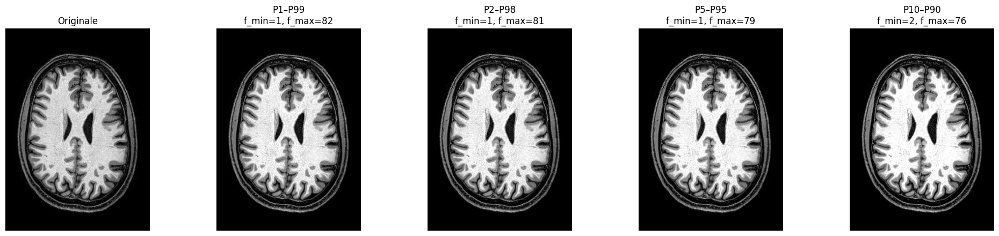

In [11]:
def transfert_lineaire(f, f_min, f_max, i_min=0.0, i_max=None):
    """i_min si f < f_min ; i_max si f > f_max ; interpolation linéaire entre les deux."""
    i_max = f.max() if i_max is None else i_max
    return np.clip((f - f_min) * (i_max - i_min) / (f_max - f_min) + i_min, i_min, i_max)

bornes = [(1, 99), (2, 98), (5, 95), (10, 90)]
resultats = [('Originale', shannon_entropy(imf), contraste_rms(imf[masque_tete]) / imf.max())]

fig, axes = plt.subplots(1, len(bornes) + 1, figsize=(4 * (len(bornes) + 1), 4.5))
axes[0].imshow(imf, cmap='gray', vmin=0, vmax=imf.max()); axes[0].set_title('Originale'); axes[0].axis('off')
for ax, (b, h) in zip(axes[1:], bornes):
    f_min, f_max = np.percentile(imf[masque_tete], [b, h])
    res = transfert_lineaire(imf, f_min, f_max, 0.0, imf.max())
    ax.imshow(res, cmap='gray', vmin=0, vmax=imf.max())
    ax.set_title(f'P{b}–P{h}\nf_min={f_min:.0f}, f_max={f_max:.0f}'); ax.axis('off')
    resultats.append((f'Étirement P{b}–P{h}', shannon_entropy(res), contraste_rms(res[masque_tete]) / imf.max()))
plt.tight_layout(); plt.show()

**Ce qu'on observe.** Les bornes calculées sur la tête sont f_min = 1 ou 2 et f_max entre 76 et 82 : l'étirement ne gagne que quelques niveaux, car l'image occupe déjà presque toute sa plage (0 à 91). Les quatre images sont visuellement proches de l'originale ; la paire P10–P90 donne le contraste le plus marqué, avec une substance blanche plus saturée.

**Ce qu'on retient.** Un étirement linéaire est réversible tant qu'il n'écrête pas. Seul l'écrêtage fusionne des niveaux et fait baisser l'entropie : plus les bornes sont serrées, plus le contraste augmente et plus l'information diminue.

### 3.3 Synthèse comparative

Toutes les méthodes sont comparées sur les deux mêmes critères. Le contraste RMS est calculé sur la tête seule, après normalisation de chaque image dans [0, 1] pour que les échelles soient comparables.

                      Traitement  Entropie (bits)  Contraste RMS (tête, échelle 0–1)
                       Originale           4.5238                             0.3054
                Étirement P1–P99           4.3218                             0.3428
                Étirement P2–P98           4.3093                             0.3468
                Étirement P5–P95           4.2626                             0.3547
               Étirement P10–P90           3.9862                             0.3685
             Égalisation globale           4.5238                             0.1667
Égalisation restreinte à la tête           4.3389                             0.2865
                           CLAHE              NaN                             0.2957

Entropie sur 256 niveaux : originale = 4.5238 bits ; CLAHE = 5.6917 bits


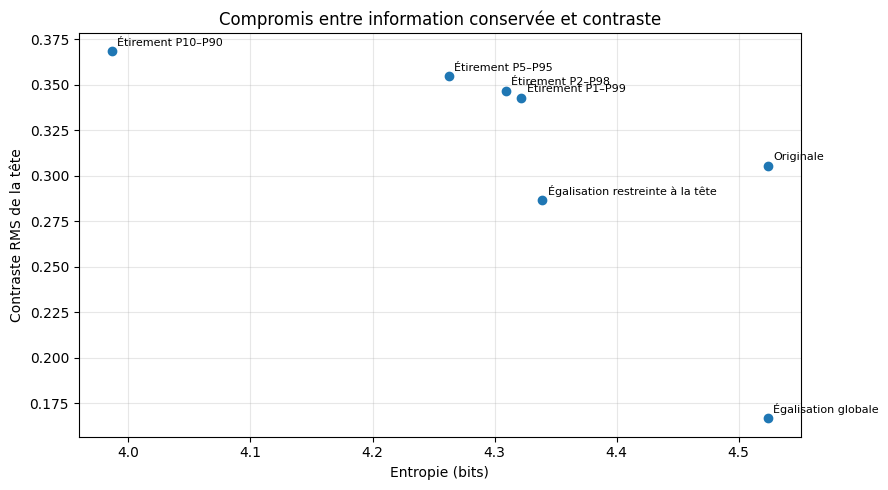

In [12]:
resultats.append(("Égalisation globale", shannon_entropy(im_eq), contraste_rms(im_eq[masque_tete])))
resultats.append(("Égalisation restreinte à la tête", shannon_entropy(im_eq_tete), contraste_rms(im_eq_tete[masque_tete])))
# CLAHE interpole entre régions et fabrique de nouvelles valeurs flottantes : l'entropie calculée sur les
# valeurs uniques serait artificiellement gonflée. On la laisse vide ici et on compare ci-dessous sur 256 niveaux.
resultats.append(("CLAHE", np.nan, contraste_rms(im_clahe[masque_tete])))

synthese = pd.DataFrame(resultats, columns=['Traitement', 'Entropie (bits)', 'Contraste RMS (tête, échelle 0–1)']).round(4)
print(synthese.to_string(index=False))

def entropie_256(a):
    """Entropie après quantification sur 256 niveaux (a dans [0, 1]) : comparaison équitable avec le CLAHE."""
    return shannon_entropy(np.round(a * 255).astype(np.uint8))

print(f"\nEntropie sur 256 niveaux : originale = {entropie_256(imn):.4f} bits ; CLAHE = {entropie_256(im_clahe):.4f} bits")

pts = synthese.dropna()
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(pts['Entropie (bits)'], pts['Contraste RMS (tête, échelle 0–1)'])
for _, row in pts.iterrows():
    ax.annotate(row['Traitement'], (row['Entropie (bits)'], row['Contraste RMS (tête, échelle 0–1)']),
                fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Entropie (bits)'); ax.set_ylabel('Contraste RMS de la tête')
ax.set_title('Compromis entre information conservée et contraste'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Ce qu'on observe.**

| Traitement | Entropie (bits) | Contraste RMS (tête, 0–1) |
|---|---|---|
| Originale | 4,5238 | 0,3054 |
| Étirement P1–P99 | 4,3218 | 0,3428 |
| Étirement P2–P98 | 4,3093 | 0,3468 |
| Étirement P5–P95 | 4,2626 | 0,3547 |
| Étirement P10–P90 | 3,9862 | 0,3685 |
| Égalisation globale | 4,5238 | 0,1667 |
| Égalisation restreinte à la tête | 4,3389 | 0,2865 |
| CLAHE | non comparable (voir ci-dessous) | 0,2957 |

Entropie sur 256 niveaux : originale 4,5238 bits, CLAHE 5,6917 bits.

- **Étirement linéaire** : l'entropie baisse de 4,5238 à 4,3218 bits pour P1–P99 (− 4,5 %), puis jusqu'à 3,9862 bits pour P10–P90 (− 11,9 %), tandis que le contraste RMS de la tête passe de 0,3054 à 0,3428 (+ 12 %) puis à 0,3685 (+ 21 %). On gagne en contraste en sacrifiant de l'information (écrêtage).
- **Égalisation globale** : l'entropie est conservée, mais le contraste RMS de la tête **chute** à 0,1667. Explication chiffrée : le fond (41,8 % des pixels) est envoyé vers le niveau 0,42 ; la tête n'occupe plus que l'intervalle [0,42 ; 1], soit 58 % de la plage. L'écart-type d'une loi uniforme sur cet intervalle vaut 0,58/√12 ≈ 0,167, ce qui correspond à la valeur mesurée.
- **Égalisation restreinte à la tête** : elle redonne à la tête toute la plage et évite l'effondrement (0,1667 → 0,2865), mais elle ne dépasse pas le contraste d'origine (0,3054). C'est cohérent : une répartition uniforme sur [0, 1] a un écart-type de 1/√12 ≈ 0,29, alors que l'histogramme d'origine est bimodal (substance grise et substance blanche) donc plus dispersé. Le RMS récompense l'écart entre les deux populations, pas l'uniformité de l'histogramme. Son entropie baisse de 0,19 bit à cause de la fusion des niveaux 0 et 1.
- **CLAHE** : son entropie ne peut pas être calculée comme pour les autres méthodes. L'interpolation entre régions crée de nouvelles valeurs flottantes, ce qui gonfle artificiellement l'entropie calculée sur les valeurs uniques (elle pourrait même dépasser le maximum de l'image d'origine). La comparaison équitable est faite sur 256 niveaux : 5,6917 bits pour le CLAHE contre 4,5238 pour l'originale. Cette hausse est à interpréter avec prudence : l'interpolation locale crée des niveaux intermédiaires (l'image d'origine n'en compte que 92) et fait ressortir du grain, ce qui n'est pas de l'information nouvelle. Son contraste RMS (0,2957) est proche de celui de l'originale.

**Ce qu'on retient.** Pour toute transformation d'intensité globale (une même valeur d'entrée donne toujours la même valeur de sortie), l'entropie ne peut que se conserver ou baisser. Le gain de contraste se paie donc en information (écrêtage), ou se perd si le fond n'est pas traité (égalisation globale). Le CLAHE, qui est local, n'obéit pas à cette règle. Le bon choix dépend de l'usage : lecture visuelle des tissus, ou prétraitement avant une segmentation.

## 4. Segmentation par seuillage et morphologie mathématique

Segmenter, c'est isoler des structures d'intérêt. On procède en deux temps : un **seuillage** transforme l'image en masque binaire (objet / fond), puis la **morphologie mathématique** nettoie ce masque avec un élément structurant, ici un disque :

- **érosion** : réduit les objets et supprime les petits objets blancs ;
- **dilatation** : agrandit les objets et comble les petits trous ;
- **ouverture** (érosion puis dilatation) : supprime les petits objets blancs sans réduire les gros ;
- **fermeture** (dilatation puis érosion) : comble les petits trous noirs sans agrandir les gros.

Un point de méthode commun à toutes les applications qui suivent : aux bords de l'image, les opérateurs manquent de voisins et rongent les structures qui touchent le bord. On évite cet artefact en prolongeant l'image par réplication des bords avant le traitement, puis en recadrant.

In [13]:
def avec_bords(operateur, masque_u8, rayon):
    """Applique un opérateur morphologique après prolongement de l'image (mode 'edge'), pour éviter les artefacts de bord."""
    p = 2 * rayon + 1
    res = operateur(np.pad(masque_u8, p, mode='edge'), disk(rayon))
    return res[p:-p, p:-p]

def ouverture_fermeture(masque_u8, rayon):
    """Ouverture (supprime les grains blancs) puis fermeture (comble les grains noirs), avec gestion des bords."""
    p = 2 * rayon + 1
    se = disk(rayon)
    res = closing(opening(np.pad(masque_u8, p, mode='edge'), se), se)
    return res[p:-p, p:-p]

### 4.1 Nettoyage d'une image binaire (`cell.png`)

**Objectif.** Supprimer les petits grains blancs et noirs d'une image binaire en conservant les structures principales.

**Méthode.** Ouverture (grains blancs) puis fermeture (grains noirs) avec un disque de rayon r. On compare r = 1 à 4 avec deux mesures : le nombre d'objets blancs (composantes connexes) et la fraction de surface blanche.

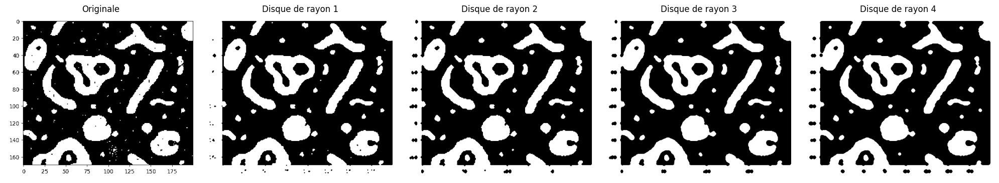

Traitement  Objets blancs  Surface blanche (fraction)
 Originale            119                       0.415
   Rayon 1             38                       0.416
   Rayon 2             30                       0.410
   Rayon 3             27                       0.409
   Rayon 4             26                       0.406


In [14]:
im_cell = io.imread(CELL_FILE)
if im_cell.ndim == 3:
    im_cell = color.rgb2gray(im_cell[..., :3])        # sécurité si l'image est en couleur
binaire_u8 = (im_cell > threshold_otsu(im_cell)).astype(np.uint8) * 255

rayons = [1, 2, 3, 4]
lignes = [('Originale', label(binaire_u8 > 0).max(), (binaire_u8 > 0).mean())]
fig, axes = plt.subplots(1, len(rayons) + 1, figsize=(4 * (len(rayons) + 1), 4))
axes[0].imshow(binaire_u8, cmap='gray'); axes[0].set_title('Originale'); axes[0].axis('off')
for ax, r in zip(axes[1:], rayons):
    nettoyee = ouverture_fermeture(binaire_u8, r)
    ax.imshow(nettoyee, cmap='gray'); ax.set_title(f'Disque de rayon {r}'); ax.axis('off')
    lignes.append((f'Rayon {r}', label(nettoyee > 0).max(), (nettoyee > 0).mean()))
plt.tight_layout(); plt.show()

print(pd.DataFrame(lignes, columns=['Traitement', 'Objets blancs', 'Surface blanche (fraction)']).round(3).to_string(index=False))

**Ce qu'on observe.** Le nombre d'objets blancs passe de 119 à 38 dès le rayon 1 (suppression des grains isolés), puis à 30, 27 et 26 pour les rayons 2, 3 et 4, tandis que la surface blanche reste presque constante (0,415 → 0,406) : le gain devient marginal après le rayon 3. Les rayons les plus grands ne retirent plus que quelques petites structures et commencent à arrondir et à relier les formes principales. Avec un rayon 2, de petits résidus en forme de losange subsistent ; un rayon plus grand les supprime mais déforme davantage les contours.

**Ce qu'on retient.** Le choix du rayon est un compromis entre propreté du résultat et fidélité des formes ; le tableau montre où le gain devient marginal. Le prolongement des bords est indispensable : sans lui, les structures qui touchent le bord de l'image sont rongées.

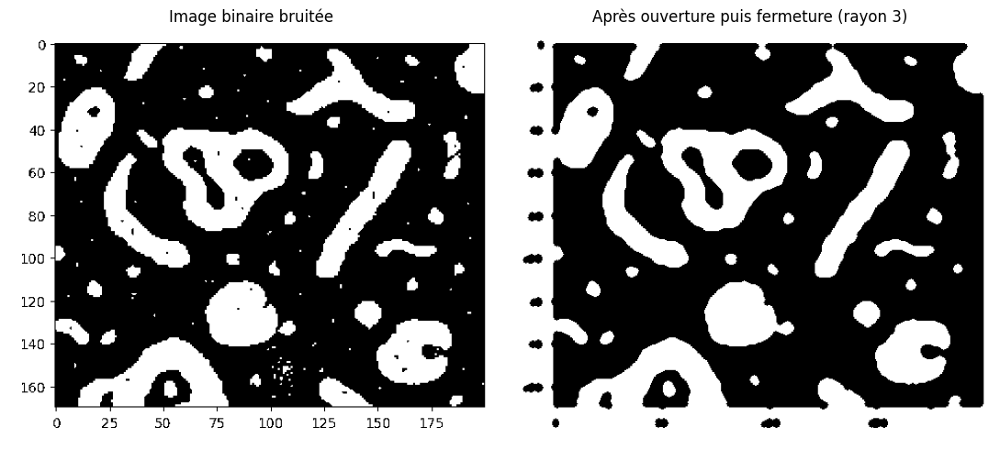

In [15]:
RAYON_CELL = 3           # retenu d'après le tableau et les images ci-dessus

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(binaire_u8, cmap='gray'); ax[0].set_title('Image binaire bruitée'); ax[0].axis('off')
ax[1].imshow(ouverture_fermeture(binaire_u8, RAYON_CELL), cmap='gray')
ax[1].set_title(f'Après ouverture puis fermeture (rayon {RAYON_CELL})'); ax[1].axis('off')
plt.tight_layout(); plt.show()

### 4.2 Détection de marqueurs sur une coupe IRM (`N2D_0001`)

**Objectif.** Isoler les 4 petits points brillants visibles sur la coupe `N2D_0001`, une coupe axiale passant par le cou.

**Difficulté.** Ces points se trouvent dans la **partie haute du corps**, mais celle-ci commence au milieu de l'image : le haut de l'image est du fond noir. Une zone d'analyse fixée à la main sur les premières lignes ne contient donc que des zéros, et le seuil calculé y vaut 0. Par ailleurs, les 4 points ne représentent qu'une infime fraction des pixels : un seuil d'Otsu calculé sur tous les pixels est dominé par le tissu.

**Méthode.**
1. Localiser automatiquement le corps (pixels non nuls) et restreindre l'analyse à sa partie haute.
2. Appliquer le seuil d'Otsu à la **queue** de l'histogramme (pixels les plus brillants), puis vérifier sa **robustesse** : un bon seuil donne le même nombre d'objets sur une plage de valeurs voisines.
3. Binariser, nettoyer par morphologie, compter les composantes connexes avec leur aire, leur diamètre équivalent (grâce à la résolution physique des pixels) et leur centre.

Géométrie de la coupe (métadonnées techniques) :
  SliceLocation           : non renseigné
  ImagePositionPatient    : [-91.4495864331908, -160.06035870244, -142.505487236053]
  ImageOrientationPatient : [0.999032176441525, -0.0217883751691557, 0.0382096472372976, 0.026519476938784, 0.991413870277297, -0.128043957939]
  PixelSpacing            : [0.666666686534882, 0.699987828731537]
Dimensions : (384, 274) ; intensités de 0 à 99 ; part de zéros : 55.6%


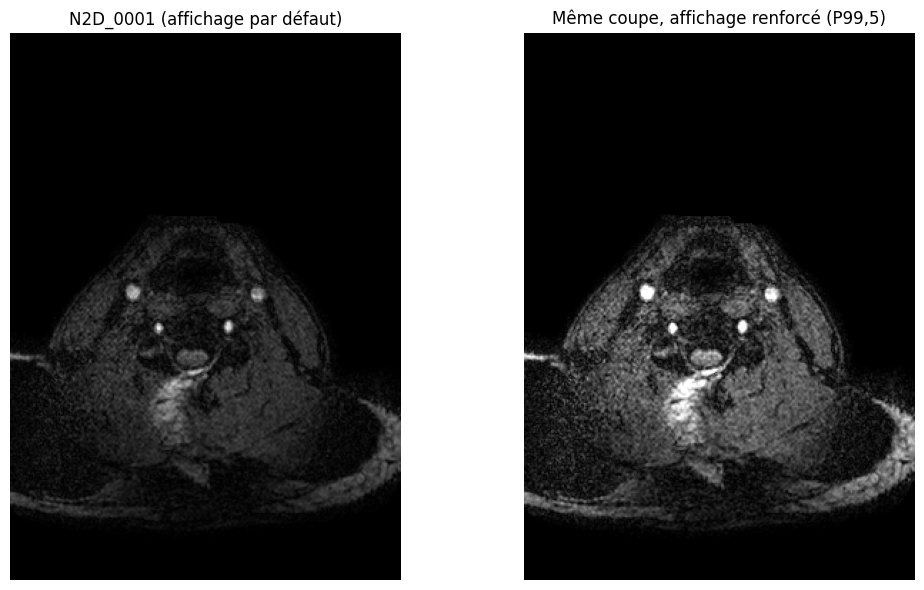

In [16]:
ds1 = dcmread(DICOM_MARQUEURS)
im1 = ds1.pixel_array.astype(float)

print("Géométrie de la coupe (métadonnées techniques) :")
for tag in ['SliceLocation', 'ImagePositionPatient', 'ImageOrientationPatient', 'PixelSpacing']:
    print(f"  {tag:24s}: {getattr(ds1, tag, 'non renseigné')}")
pas_l1, pas_c1 = (float(v) for v in ds1.PixelSpacing)
print(f"Dimensions : {im1.shape} ; intensités de {im1.min():.0f} à {im1.max():.0f} ; part de zéros : {(im1 == 0).mean():.1%}")

vmax_aff = np.percentile(im1[im1 > 0], 99.5)       # fenêtre d'affichage renforcée (l'image est sombre)
fig, ax = plt.subplots(1, 2, figsize=(11, 6))
ax[0].imshow(im1, cmap='gray'); ax[0].set_title('N2D_0001 (affichage par défaut)')
ax[1].imshow(im1, cmap='gray', vmax=vmax_aff); ax[1].set_title('Même coupe, affichage renforcé (P99,5)')
for a in ax:
    a.axis('off')
plt.tight_layout(); plt.show()

**Ce qu'on observe.** La coupe se situe au niveau du cou, ce que montrent la colonne vertébrale et le contour des épaules, et ce qui est cohérent avec une position basse (z = −142,5 mm dans `ImagePositionPatient`). Les 4 points d'intérêt se trouvent au milieu de l'image (lignes 180 à 210 environ) et non tout en haut, d'où la nécessité de recentrer la zone d'analyse. Ils apparaissent comme de petits objets ronds et très brillants.


Corps : lignes 128 à 356 ; zone analysée : lignes 128 à 231 (103 × 274 pixels)
Otsu sur tous les pixels non nuls : 13.8  |  Otsu sur la queue (> P90) : 43.0


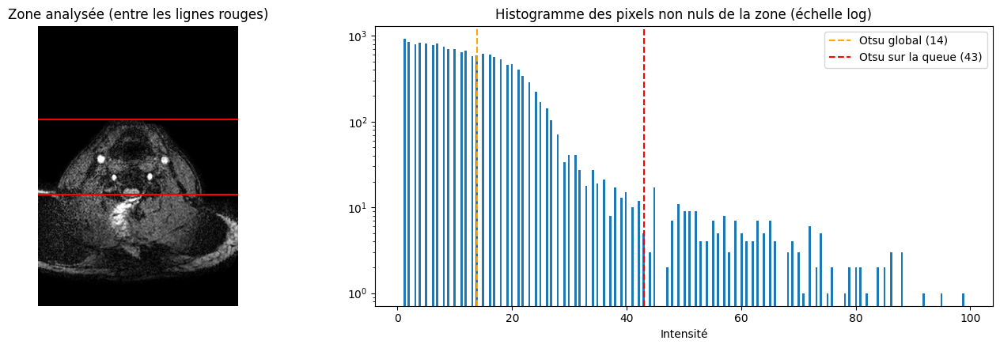

 Facteur  Seuil  Nombre d'objets
     0.6   25.8               11
     0.7   30.1                8
     0.8   34.4                6
     0.9   38.7                5
     1.0   43.0                4
     1.1   47.3                4
     1.2   51.6                4
     1.3   56.0                4
     1.4   60.3                4


In [17]:
# 1) Zone d'analyse : le corps (pixels non nuls), puis sa partie haute
corps = closing(((im1 > 0) * 255).astype(np.uint8), disk(3)) > 0
etiq = label(corps)
corps = ndi.binary_fill_holes(etiq == (np.argmax(np.bincount(etiq.ravel())[1:]) + 1))   # plus grande composante
lignes_corps = np.where(corps.any(axis=1))[0]
haut_corps = lignes_corps.min()
hauteur_corps = lignes_corps.max() - haut_corps + 1

FRACTION = 0.45                                    # part de la hauteur du corps analysée (à ajuster)
L0, L1 = int(haut_corps), int(haut_corps + FRACTION * hauteur_corps)
roi = im1[L0:L1, :]
print(f"Corps : lignes {haut_corps} à {lignes_corps.max()} ; zone analysée : lignes {L0} à {L1} ({roi.shape[0]} × {roi.shape[1]} pixels)")

# 2) Seuil : Otsu appliqué à la queue de l'histogramme (les 4 points sont une infime fraction des pixels)
tissus = roi[roi > 0]
seuil_naif = threshold_otsu(tissus)
seuil_otsu = threshold_otsu(tissus[tissus > np.percentile(tissus, 90)])
print(f"Otsu sur tous les pixels non nuls : {seuil_naif:.1f}  |  Otsu sur la queue (> P90) : {seuil_otsu:.1f}")

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].imshow(im1, cmap='gray', vmax=vmax_aff)
ax[0].axhline(L0, color='r'); ax[0].axhline(L1, color='r'); ax[0].set_title('Zone analysée (entre les lignes rouges)'); ax[0].axis('off')
h, c = exposure.histogram(tissus, nbins=256)
ax[1].bar(c, h, width=(c[1] - c[0])); ax[1].set_yscale('log')
ax[1].axvline(seuil_naif, color='orange', ls='--', label=f'Otsu global ({seuil_naif:.0f})')
ax[1].axvline(seuil_otsu, color='r', ls='--', label=f'Otsu sur la queue ({seuil_otsu:.0f})')
ax[1].set_title('Histogramme des pixels non nuls de la zone (échelle log)'); ax[1].set_xlabel('Intensité'); ax[1].legend()
plt.tight_layout(); plt.show()

# 3) Robustesse du seuil : nombre d'objets pour des seuils autour de la valeur retenue
facteurs = np.round(np.arange(0.6, 1.41, 0.1), 2)
robustesse = pd.DataFrame({'Facteur': facteurs, 'Seuil': (facteurs * seuil_otsu).round(1)})
robustesse["Nombre d'objets"] = [label(avec_bords(opening, ((roi > s) * 255).astype(np.uint8), 1) > 0).max() for s in robustesse['Seuil']]
print(robustesse.to_string(index=False))

**Ce qu'on observe.** Le seuil d'Otsu global calculé sur la zone du corps est de 13.8 (il sépare globalement le tissu des zones plus sombres), tandis que le seuil calculé sur la queue de l'histogramme (> P90) est nettement plus élevé, à 43.0. Le tableau de robustesse montre qu'on obtient exactement 4 objets pour un facteur allant de 1.0 (seuil 43.0) à 1.4 (seuil 60.3). Plus bas, des objets parasites apparaissent dès le facteur 0.9 (5 objets) et jusqu'à 11 objets pour 0.6. Le comportement au-delà de 1.4 n'a pas été testé.

**Ce qu'on retient.** Le seuil retenu (43.0, valeur d'Otsu sur la queue) se situe au bord inférieur d'un plateau à 4 objets (43.0 à 60.3) : le résultat est stable pour des seuils plus élevés, mais une baisse de 10 % suffit à faire apparaître un objet parasite. Un seuil pris au milieu du plateau serait plus sûr ; on garde ici la valeur d'Otsu, qui ne demande aucun réglage manuel.


4 objets détectés (attendu : 4)
 Objet  Aire (px)  Diamètre équivalent (mm) Centre (ligne, colonne)  Solidité
     1         68                       6.4               (181, 85)      0.94
     2         33                       4.4              (184, 173)      0.87
     3         35                       4.6              (205, 152)      1.00
     4         24                       3.8              (206, 103)      0.96


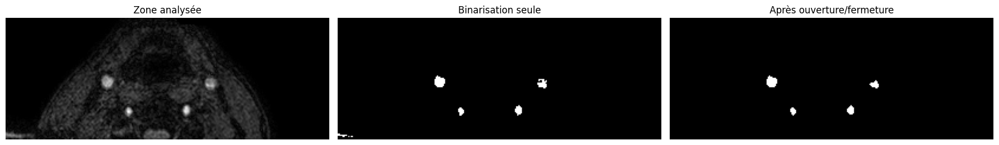

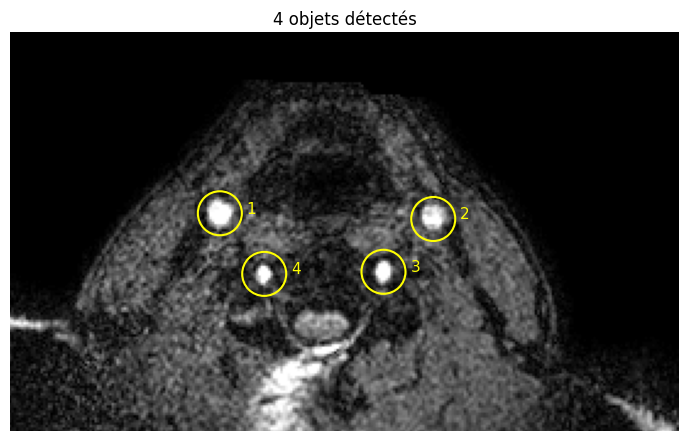

In [18]:
# 4) Binarisation, morphologie, comptage
SEUIL = seuil_otsu                        # à remplacer par une valeur choisie sur le plateau du tableau ci-dessus si besoin
bw = roi > SEUIL
nettoye = ouverture_fermeture(bw.astype(np.uint8) * 255, 1) > 0
lab = label(nettoye)
print(f"{lab.max()} objets détectés (attendu : 4)")

lignes_tab = []
for r in regionprops(lab):
    aire_mm2 = r.area * pas_l1 * pas_c1
    lignes_tab.append({'Objet': r.label, 'Aire (px)': int(r.area),
                       'Diamètre équivalent (mm)': round(2 * np.sqrt(aire_mm2 / np.pi), 1),
                       'Centre (ligne, colonne)': (int(r.centroid[0] + L0), int(r.centroid[1])),
                       'Solidité': round(r.solidity, 2)})
print(pd.DataFrame(lignes_tab).to_string(index=False))

fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
for a, img_, t in zip(ax, [roi, bw, nettoye], ['Zone analysée', 'Binarisation seule', 'Après ouverture/fermeture']):
    a.imshow(img_, cmap='gray'); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(im1, cmap='gray', vmax=vmax_aff)
for r in regionprops(lab):
    cy, cx = r.centroid[0] + L0, r.centroid[1]
    ax.add_patch(plt.Circle((cx, cy), 9, fill=False, edgecolor='yellow', linewidth=1.5))
    ax.text(cx + 11, cy, str(r.label), color='yellow', fontsize=11)
ax.set_xlim(0, im1.shape[1]); ax.set_ylim(L1 + 40, L0 - 20)
ax.set_title(f'{lab.max()} objets détectés'); ax.axis('off')
plt.tight_layout(); plt.show()

**Ce qu'on observe.** Après binarisation et morphologie mathématique, on obtient exactement 4 objets. Leurs aires varient de 24 à 68 pixels, ce qui correspond à des diamètres équivalents allant de 3.8 mm à 6.4 mm. Ils sont positionnés dans la zone centrale de l'image (lignes 181 à 206). La morphologie a permis d'éliminer le bruit et les petites irrégularités de la binarisation pour ne conserver que les objets principaux compacts.

**Ce qu'on retient.** Les 4 points isolés sont très brillants, compacts (avec une solidité très élevée de 0.87 à 1.00) et mesurent quelques millimètres de diamètre. Ces caractéristiques sont compatibles avec des vaisseaux sanguins vus en coupe (par exemple, les artères carotides et vertébrales). Toutefois, cette hypothèse anatomique reste à confirmer avec la source des données.


### 4.3 Comptage d'objets sur une image satellite (`moliets.png`)

**Objectif.** Compter les piscines d'un lotissement sur une image satellite. C'est une application hors du médical du même enchaînement : seuillage, morphologie, analyse de régions.

**Difficulté.** Les piscines ne représentent qu'une faible fraction des pixels, ce qui met en défaut les méthodes de seuillage automatique usuelles.

#### a) Choix de la bande

Une piscine reflète un bleu-cyan : peu de rouge, beaucoup de bleu. On compare plusieurs représentations : les trois canaux, la teinte et la saturation (HSV), et l'excès de bleu sur le rouge (B − R).

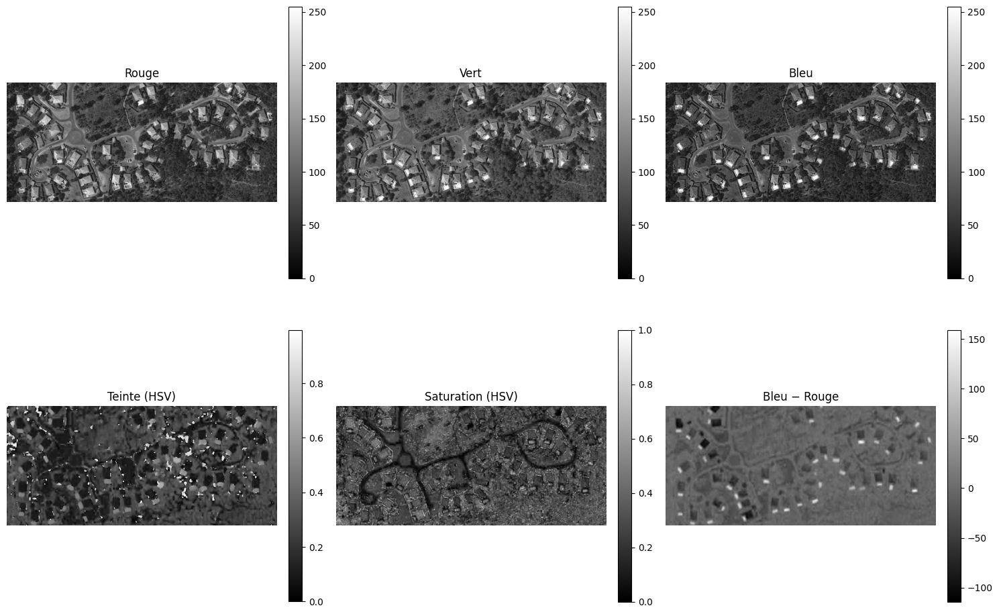

In [19]:
img = io.imread(MOLIETS_FILE)
if img.ndim == 3 and img.shape[-1] == 4:
    img = img[..., :3]                                   # retire le canal alpha
r, g, b = (img[..., k].astype(float) for k in range(3))
hsv = color.rgb2hsv(img)
canaux = {'Rouge': r, 'Vert': g, 'Bleu': b,
          'Teinte (HSV)': hsv[..., 0], 'Saturation (HSV)': hsv[..., 1], 'Bleu − Rouge': b - r}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (nom, canal) in zip(axes.ravel(), canaux.items()):
    h = ax.imshow(canal, cmap='gray'); ax.set_title(nom); ax.axis('off')
    fig.colorbar(h, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

**Ce qu'on observe.** Dans les canaux Rouge, Vert et Bleu, les piscines se confondent avec les toits clairs. La teinte est bruitée (instable pour les pixels peu saturés). Dans « Bleu − Rouge », les piscines ressortent en blanc sur un fond gris quasi uniforme, tandis que les toits (rouge élevé) tombent à des valeurs fortement négatives.

**Ce qu'on retient.** L'excès de bleu sur le rouge est la bande la plus discriminante : elle sépare les piscines à la fois des toits et de la végétation.

#### b) Seuillage

Le seuil d'Otsu suppose deux classes de poids comparable. Ici, les piscines sont minoritaires : appliqué à toute l'image, il sépare plutôt la forêt sombre du reste. On compare donc ce seuil « naïf » à un Otsu appliqué aux seuls pixels où le bleu l'emporte sur le rouge (B − R > 0), qui sépare un faible excès de bleu (ombres, feuillage) d'un fort excès de bleu (eau).

Otsu sur toute l'image       : seuil =  -19.6 ->  77.3% des pixels dans le masque
Otsu sur les pixels où B > R : seuil =   39.0 ->   1.7% des pixels dans le masque


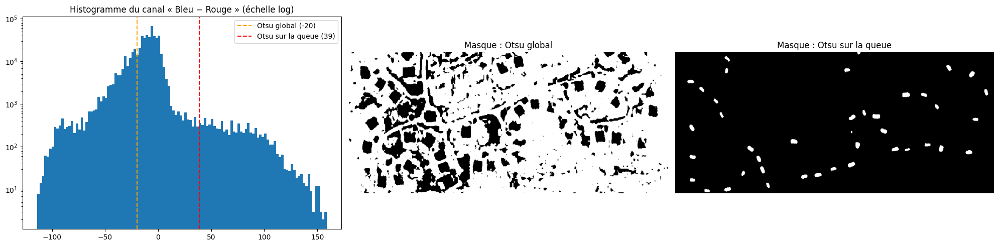

In [20]:
CANAL = 'Bleu − Rouge'
canal = canaux[CANAL]

seuil_naif = threshold_otsu(canal)                  # Otsu sur toute l'image
seuil = threshold_otsu(canal[canal > 0])            # Otsu sur les seuls pixels où B > R
masque = canal > seuil
print(f"Otsu sur toute l'image       : seuil = {seuil_naif:6.1f} -> {(canal > seuil_naif).mean():6.1%} des pixels dans le masque")
print(f"Otsu sur les pixels où B > R : seuil = {seuil:6.1f} -> {masque.mean():6.1%} des pixels dans le masque")

fig, ax = plt.subplots(1, 3, figsize=(20, 5))
ax[0].hist(canal.ravel(), bins=120, log=True)
ax[0].axvline(seuil_naif, color='orange', ls='--', label=f'Otsu global ({seuil_naif:.0f})')
ax[0].axvline(seuil, color='r', ls='--', label=f'Otsu sur la queue ({seuil:.0f})')
ax[0].set_title(f'Histogramme du canal « {CANAL} » (échelle log)'); ax[0].legend()
ax[1].imshow(canal > seuil_naif, cmap='gray'); ax[1].set_title('Masque : Otsu global'); ax[1].axis('off')
ax[2].imshow(masque, cmap='gray'); ax[2].set_title('Masque : Otsu sur la queue'); ax[2].axis('off')
plt.tight_layout(); plt.show()

**Ce qu'on observe.** Le seuil d'Otsu global tombe dans la masse de l'histogramme (−19,6) et classe 77,3 % des pixels en « piscine » : le masque est inutilisable. L'Otsu appliqué à la queue de l'histogramme donne un seuil de 39,0 et ne retient que 1,7 % des pixels, ordre de grandeur compatible avec la surface occupée par des piscines.

**Vérification de la robustesse.** On regarde le nombre de régions obtenu pour une plage de seuils : un bon seuil se situe sur un plateau où ce nombre ne varie presque pas.

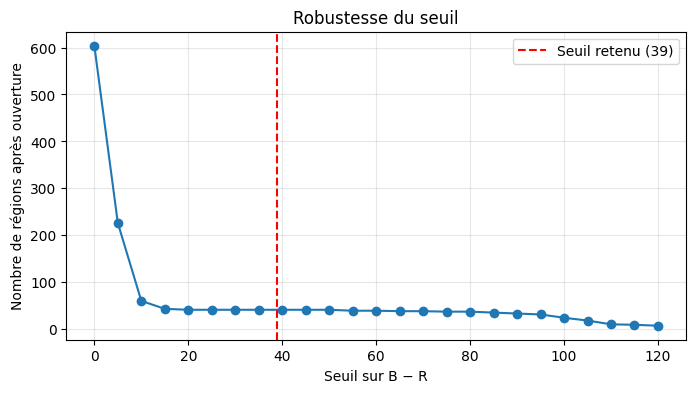

In [21]:
RAYON_SAT = 1            # rayon des opérateurs morphologiques (en pixels) : à ajuster selon la résolution de l'image

seuils = np.arange(0, 121, 5)
nb_regions = [label(avec_bords(opening, ((canal > s) * 255).astype(np.uint8), RAYON_SAT) > 0).max() for s in seuils]

plt.figure(figsize=(8, 4))
plt.plot(seuils, nb_regions, 'o-')
plt.axvline(seuil, color='r', ls='--', label=f'Seuil retenu ({seuil:.0f})')
plt.xlabel('Seuil sur B − R'); plt.ylabel('Nombre de régions après ouverture')
plt.title('Robustesse du seuil'); plt.legend(); plt.grid(alpha=0.3); plt.show()

**Ce qu'on retient.** Le seuil retenu (39) se situe sur un plateau : d'après la courbe, le nombre de régions reste autour de 40 entre un seuil d'environ 15 et un seuil d'environ 85, il ne dépend donc pas d'un réglage fin. Pour des seuils trop bas, des régions parasites (ombres, feuillage) apparaissent ou fusionnent ; pour des seuils trop hauts, les piscines les moins bleues disparaissent.

#### c) Choix de l'opérateur morphologique

On compare les quatre opérateurs sur le masque obtenu. L'ouverture élimine les petits faux positifs isolés ; la fermeture comble les trous à l'intérieur d'une piscine (reflets, par exemple).

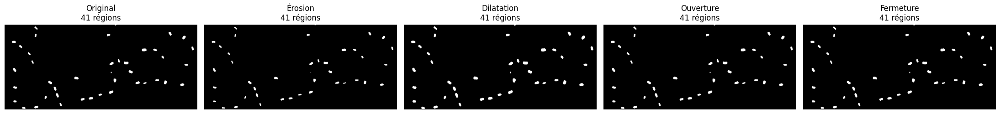

In [22]:
masque_u8 = masque.astype(np.uint8) * 255
operateurs = {'Original': None, 'Érosion': erosion, 'Dilatation': dilation, 'Ouverture': opening, 'Fermeture': closing}

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, (nom, f) in zip(axes, operateurs.items()):
    out = masque_u8 if f is None else avec_bords(f, masque_u8, RAYON_SAT)
    ax.imshow(out, cmap='gray'); ax.set_title(f'{nom}\n{label(out > 0).max()} régions'); ax.axis('off')
plt.tight_layout(); plt.show()

**Ce qu'on retient.** L'ouverture suivie d'une fermeture est retenue : elle supprime les taches isolées sans amputer les piscines, et referme les petits trous. L'érosion seule réduit les piscines, la dilatation seule agrandit aussi les parasites.

#### d) Analyse de régions et comptage

`skimage.measure.regionprops` calcule, pour chaque région connexe étiquetée, des propriétés (aire, centre, boîte englobante, excentricité, solidité…). Les piscines ayant des tailles comparables, on filtre les régions par leur **aire**. Les bornes sont exprimées relativement à l'aire médiane des régions (de 0,35 à 4 fois la médiane) : elles ne dépendent donc pas de la résolution de l'image.

41 régions au total ; aire médiane = 227 px ; 39 retenues comme piscines


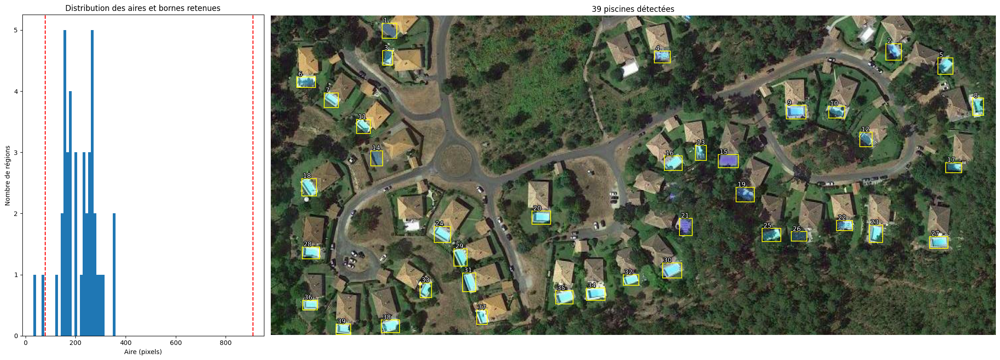

In [23]:
nettoye = ouverture_fermeture(masque_u8, RAYON_SAT) > 0
regions = regionprops(label(nettoye))

aires = np.array([r.area for r in regions])
aire_mediane = np.median(aires)
AIRE_MIN, AIRE_MAX = 0.35 * aire_mediane, 4 * aire_mediane
piscines = [r for r in regions if AIRE_MIN <= r.area <= AIRE_MAX]
print(f"{len(regions)} régions au total ; aire médiane = {aire_mediane:.0f} px ; {len(piscines)} retenues comme piscines")

fig, ax = plt.subplots(1, 2, figsize=(22, 8), gridspec_kw={'width_ratios': [1, 3]})
ax[0].hist(aires, bins=30); ax[0].axvline(AIRE_MIN, color='r', ls='--'); ax[0].axvline(AIRE_MAX, color='r', ls='--')
ax[0].set_xlabel('Aire (pixels)'); ax[0].set_ylabel('Nombre de régions'); ax[0].set_title('Distribution des aires et bornes retenues')
ax[1].imshow(img)
for k, r in enumerate(piscines, 1):
    y0, x0, y1, x1 = r.bbox
    ax[1].add_patch(plt.Rectangle((x0 - 2, y0 - 2), x1 - x0 + 4, y1 - y0 + 4, fill=False, edgecolor='yellow', linewidth=1.2))
    ax[1].text(x0, y0 - 3, str(k), color='white', fontsize=10, path_effects=[pe.withStroke(linewidth=2, foreground='black')])
ax[1].set_title(f'{len(piscines)} piscines détectées'); ax[1].axis('off')
plt.tight_layout(); plt.show()

#### e) Évaluation

Le comptage manuel (39 piscines) sert de vérité terrain. Obtenir 39 détections pour 39 piscines ne prouve pas que chaque boîte est sur une piscine : un faux positif et une piscine manquée se compensent. Il faut donc vérifier les boîtes **une par une**. Les deux vues agrandies ci-dessous servent à cela : on relève les numéros des détections qui ne sont **pas** des piscines (faux positifs) et le nombre de piscines visibles **sans** boîte (manquées).

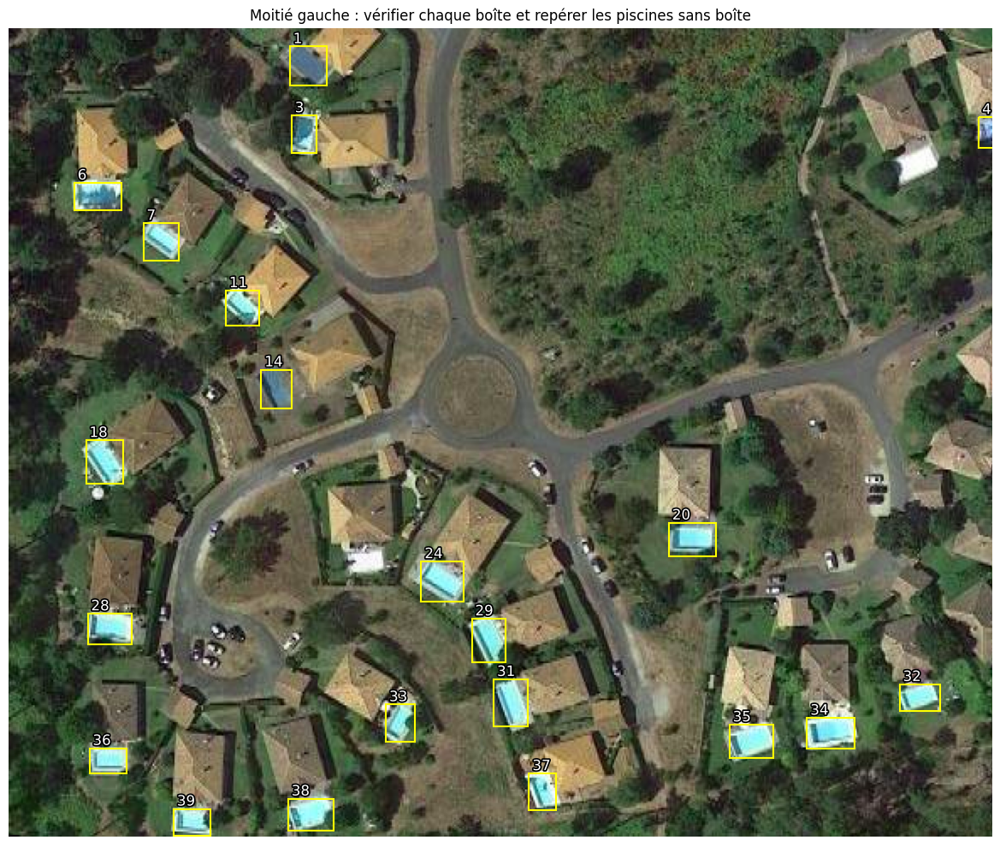

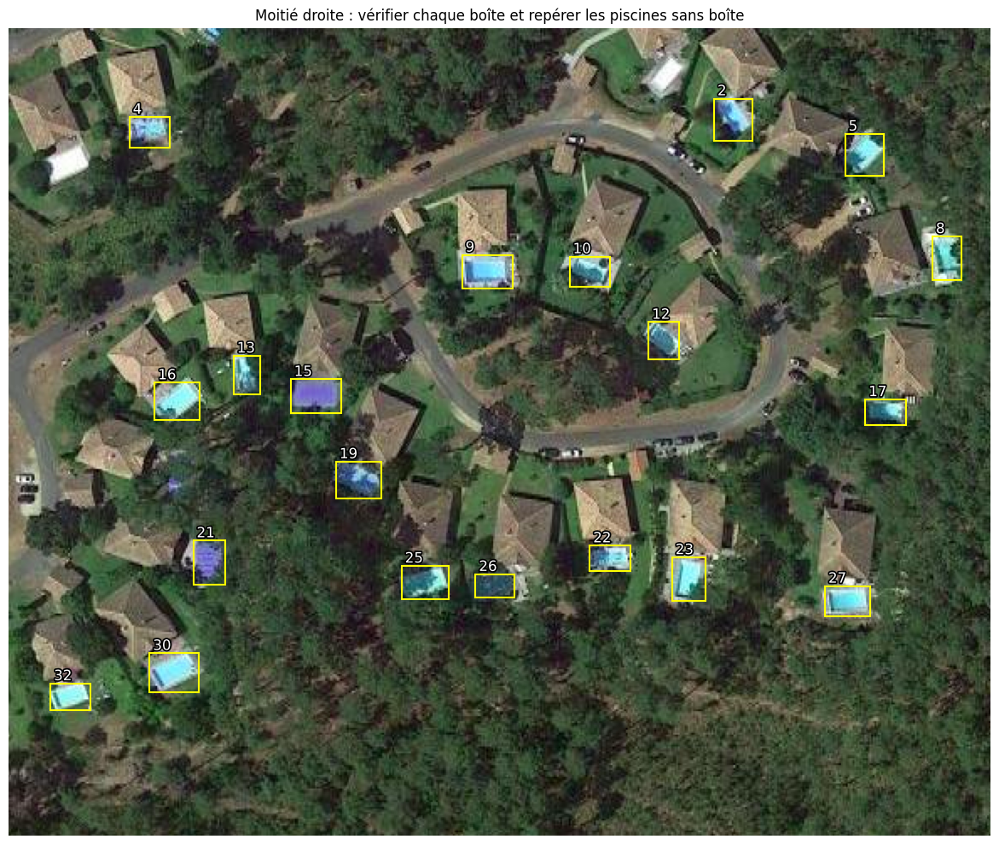

In [24]:
largeur = img.shape[1]
for moitie, (x_min, x_max) in zip(('gauche', 'droite'), [(0, largeur // 2 + 40), (largeur // 2 - 40, largeur)]):
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.imshow(img)
    for k, r in enumerate(piscines, 1):
        y0, x0, y1, x1 = r.bbox
        ax.add_patch(plt.Rectangle((x0 - 2, y0 - 2), x1 - x0 + 4, y1 - y0 + 4, fill=False, edgecolor='yellow', linewidth=1.5))
        ax.text(x0, y0 - 4, str(k), color='white', fontsize=12, clip_on=True, path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
    ax.set_xlim(x_min, x_max); ax.set_ylim(img.shape[0], 0)
    ax.set_title(f'Moitié {moitie} : vérifier chaque boîte et repérer les piscines sans boîte'); ax.axis('off')
    plt.tight_layout(); plt.show()

In [25]:
# Vérification visuelle : les 3 valeurs suivantes sont saisies à la main, seuls la précision et le rappel en sont calculés
N_MANUEL = 39                 # nombre de piscines comptées à la main
FAUX_POSITIFS = []          # numéros (affichés sur les figures) des détections qui ne sont pas des piscines
N_MANQUEES = 0             # nombre de piscines visibles sans boîte

if FAUX_POSITIFS is None or N_MANQUEES is None:
    print(f"{len(piscines)} détections pour {N_MANUEL} piscines comptées à la main. Renseigner FAUX_POSITIFS et N_MANQUEES après vérification sur les vues agrandies.")
else:
    n_det = len(piscines)
    vrais_positifs = n_det - len(FAUX_POSITIFS)
    print(f"Détections : {n_det} | vrais positifs : {vrais_positifs} | faux positifs : {len(FAUX_POSITIFS)} | piscines manquées : {N_MANQUEES}")
    print(f"Précision : {vrais_positifs / n_det:.1%} | Rappel : {vrais_positifs / (vrais_positifs + N_MANQUEES):.1%}")
    print(f"Cohérence : {vrais_positifs + N_MANQUEES} piscines au total (comptage manuel : {N_MANUEL})")

Détections : 39 | vrais positifs : 39 | faux positifs : 0 | piscines manquées : 0
Précision : 100.0% | Rappel : 100.0%
Cohérence : 39 piscines au total (comptage manuel : 39)


**Ce qu'on observe.** La chaîne produit 39 détections pour 39 piscines comptées à la main. Ces deux nombres égaux ne suffisent pas à conclure : un faux positif et une piscine manquée se compensent. La précision et le rappel imprimés par la cellule ci-dessus résultent d'une vérification boîte par boîte faite à la main sur les deux vues agrandies : les numéros des faux positifs et le nombre de piscines manquées sont saisis dans la cellule, ils ne sont pas calculés automatiquement. Les cas à regarder en priorité sont les piscines très sombres (ombre des arbres : n° 1, 13, 14, 19, 26), les deux piscines violettes (n° 15 et 21) et les petites surfaces bleues sans boîte.

**Ce qu'on retient.** Le résultat vient du **choix du seuil**, pas de l'espace colorimétrique : le canal Bleu − Rouge seuillé avec l'Otsu global, inadapté à un objet minoritaire, donne un masque inutilisable. L'Otsu appliqué à la queue de l'histogramme règle le problème. Les opérations morphologiques affinent le masque, mais elles ne pourraient pas compenser un mauvais seuil : avec l'Otsu global, le masque couvre 77,3 % de l'image.


## 5. Conclusion

Ce projet déroule une chaîne complète de traitement d'images IRM (cerveau et cou) : lecture DICOM, mesure de la qualité, rehaussement du contraste, puis segmentation.

**Résultats principaux**
- **Lecture DICOM** : coupe 384 × 274 en `int16`, dont seuls 92 niveaux (0 à 91) sont utilisés ; pixels non carrés (0,667 × 0,700 mm), corrigés à l'affichage.
- **Mesures** : le contraste de Michelson (1,0000) est peu informatif ; le contraste RMS (27,79 sur la tête) et l'entropie (4,5238 bits sur un maximum de 6,5236) décrivent mieux l'image. 41,8 % des pixels sont du fond.
- **Rehaussement** : l'étirement linéaire augmente le contraste RMS de la tête de 12 % à 21 % au prix d'une baisse d'entropie de 4,5 % à 11,9 %. L'égalisation globale conserve l'entropie mais fait tomber le contraste RMS de la tête de 0,3054 à 0,1667, car le fond accapare la plage dynamique ; la restreindre à la tête (0,2865) ou utiliser le CLAHE (0,2957) évite cet effondrement sans dépasser le contraste d'origine. Seul l'étirement linéaire l'augmente, au prix de l'entropie.
- **Morphologie** : le nettoyage d'une image binaire dépend du rayon de l'élément structurant, compromis entre propreté et fidélité des formes, et exige de traiter les bords de l'image.
- **Détection de marqueurs sur `N2D_0001`** : La méthode isole avec succès les 4 objets d'intérêt (diamètres équivalents de 3.8 à 6.4 mm, très compacts). Le seuil calculé sur la queue de l'histogramme (43.0) donne exactement 4 objets pour des facteurs de 1.0 à 1.4, mais 5 dès 0.9 : il se situe au bord inférieur du plateau. La zone d'analyse est localisée automatiquement à partir du corps, et le seuil d'Otsu est appliqué à la queue de l'histogramme parce que les points sont une infime fraction des pixels.
- **Comptage sur image satellite** : la chaîne détecte 39 objets pour 39 piscines comptées à la main ; la précision et le rappel sont calculés en 4.3 e) à partir d'une vérification visuelle boîte par boîte, saisie à la main. Le seuillage d'Otsu appliqué à toute l'image échoue quand l'objet recherché est minoritaire (77,3 % des pixels classés « piscine ») ; l'appliquer à la queue de l'histogramme (1,7 % des pixels), avec un seuil vérifié sur un plateau de robustesse, corrige le problème.

**Limites**
- Une seule coupe 2D d'un seul sujet : aucune conclusion ne se généralise à d'autres coupes ou d'autres patients.
- Les seuils des parties 4.2 et 4.3 sont choisis à la main ou par Otsu, vérifiés par un contrôle de robustesse, mais sans validation sur des données indépendantes.
- L'entropie est calculée sur les valeurs discrètes de l'image ; elle ne mesure pas la lisibilité clinique des tissus.
- Il s'agit d'un projet de traitement d'images, pas d'un outil de diagnostic.

**Pistes d'amélioration**
- Séparer automatiquement liquide, substance grise et substance blanche (par exemple avec `threshold_multiotsu`) et mesurer le contraste entre tissus.
- Étendre l'analyse au volume 3D complet plutôt qu'à une seule coupe.
- Évaluer les traitements avec une segmentation de référence plutôt qu'avec des critères globaux.